# 07 · Resultados finales y cierre de la parte práctica

Este notebook reúne en un único punto las cifras definitivas, comprueba la comparabilidad de los modelos y selecciona las tablas y figuras que pueden trasladarse a la memoria o recrearse en Power BI.

No se entrenan ni se modifican modelos en esta etapa. El notebook consume los resultados generados por los notebooks 01–06, construye la comparación final y exporta las tablas y figuras de síntesis.

MAE actúa como métrica primaria, RMSE permite controlar los errores grandes y R² contextualiza la variabilidad explicada. Cuando sus rankings difieren se presenta el compromiso entre métricas en lugar de declarar un ganador absoluto.

In [1]:
from pathlib import Path
import hashlib
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "reports").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró el raíz del proyecto (data/raw y reports).")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TABLE_DIR = ROOT / "reports" / "tables" / "07_closure"
FIGURE_DIR = ROOT / "reports" / "figures" / "07_closure"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

INPUTS = {
    "clean": PROCESSED_DIR / "player_game_clean_1718.csv",
    "model_dataset": PROCESSED_DIR / "player_pregame_target_game_3_5_1718.csv",
    "ml_summary": ROOT / "reports" / "tables" / "03_ml_benchmark" / "summary_global.csv",
    "ml_predictions": ROOT / "reports" / "tables" / "03_ml_benchmark" / "predictions.csv",
    "mlp_metrics": ROOT / "reports" / "tables" / "04_mlp" / "metrics_by_seed_fold.csv",
    "mlp_summary": ROOT / "reports" / "tables" / "04_mlp" / "summary_by_model.csv",
    "mlp_predictions": ROOT / "reports" / "tables" / "04_mlp" / "predictions.csv",
    "sequence_comparison": ROOT / "reports" / "tables" / "05_sequence" / "model_comparison.csv",
    "sequence_predictions": ROOT / "reports" / "tables" / "05_sequence" / "predictions.csv",
    "importance": ROOT / "reports" / "tables" / "06_interpretability" / "permutation_summary.csv",
    "eligibility": ROOT / "reports" / "tables" / "02_dataset" / "eligibility_impact_by_competition.csv",
}
missing = [name for name, path in INPUTS.items() if not path.exists()]
assert not missing, f"Faltan artefactos requeridos: {missing}"
input_manifest = pd.DataFrame([{"artifact": name, "path": str(path.relative_to(ROOT)), "exists": path.exists(), "bytes": path.stat().st_size} for name, path in INPUTS.items()])
input_manifest.to_csv(TABLE_DIR / "input_manifest.csv", index=False)
display(input_manifest)

,artifact,path,exists,bytes
0,clean,data\processed\player_game_clean_1718.csv,True,3904157
1,model_dataset,data\processed\player_pregame_target_game_3_5_...,True,6559239
2,ml_summary,reports\tables\03_ml_benchmark\summary_global.csv,True,1456
3,ml_predictions,reports\tables\03_ml_benchmark\predictions.csv,True,5252848
4,mlp_metrics,reports\tables\04_mlp\metrics_by_seed_fold.csv,True,5638
5,mlp_summary,reports\tables\04_mlp\summary_by_model.csv,True,464
6,mlp_predictions,reports\tables\04_mlp\predictions.csv,True,5526608
7,sequence_comparison,reports\tables\05_sequence\model_comparison.csv,True,903
8,sequence_predictions,reports\tables\05_sequence\predictions.csv,True,2792096
9,importance,reports\tables\06_interpretability\permutation...,True,9351


## Cifras fundamentales del estudio

Antes de comparar modelos se comprueban población, objetivo, registro de variables y calendario. Esta tabla actúa como referencia breve para redactar metodología y resultados sin copiar cifras de celdas aisladas.

In [2]:
clean = pd.read_csv(INPUTS["clean"], low_memory=False)
model_dataset = pd.read_csv(INPUTS["model_dataset"], low_memory=False)
feature_manifest = pd.read_csv(ROOT / "reports" / "tables" / "03_ml_benchmark" / "feature_manifest.csv")
fold_schedule = pd.read_csv(ROOT / "reports" / "tables" / "03_ml_benchmark" / "fold_schedule.csv")
sequence_features = pd.read_csv(ROOT / "reports" / "tables" / "05_sequence" / "feature_manifest.csv")

key_numbers = pd.DataFrame([
    {"concept": "raw_rows", "value": 11_475, "unit": "rows", "source": "01"},
    {"concept": "clean_rows", "value": len(clean), "unit": "rows", "source": "01"},
    {"concept": "model_rows", "value": len(model_dataset), "unit": "rows", "source": "02"},
    {"concept": "players", "value": model_dataset["player_id"].nunique(), "unit": "operational identities", "source": "02"},
    {"concept": "tabular_features", "value": len(feature_manifest), "unit": "features", "source": "03"},
    {"concept": "temporal_folds", "value": len(fold_schedule), "unit": "folds", "source": "03"},
    {"concept": "dl_seeds", "value": 3, "unit": "seeds", "source": "04-05"},
    {"concept": "sequence_length", "value": 10, "unit": "previous games", "source": "05"},
    {"concept": "sequence_timestep_features", "value": int((sequence_features["role"] == "sequence_timestep").sum()), "unit": "features", "source": "05"},
])
assert key_numbers.set_index("concept").loc["clean_rows", "value"] == 10_577
assert key_numbers.set_index("concept").loc["model_rows", "value"] == 7_269
assert key_numbers.set_index("concept").loc["players", "value"] == 712
assert key_numbers.set_index("concept").loc["tabular_features", "value"] == 36
key_numbers.to_csv(TABLE_DIR / "key_numbers.csv", index=False)
display(key_numbers)

,concept,value,unit,source
0,raw_rows,11475,rows,01
1,clean_rows,10577,rows,01
2,model_rows,7269,rows,02
3,players,712,operational identities,02
4,tabular_features,36,features,03
5,temporal_folds,5,folds,03
6,dl_seeds,3,seeds,04-05
7,sequence_length,10,previous games,05
8,sequence_timestep_features,17,features,05


## Comparación final de modelos

Las métricas de redes neuronales se promedian primero entre semillas dentro de cada fold y después entre folds. Lasso y ElasticNet son deterministas. Este orden mantiene los cinco periodos futuros como unidades comparables.

Se añaden rankings separados para MAE, RMSE y R². Un modelo puede liderar una métrica y no otra.

In [3]:
master_results = pd.read_csv(INPUTS["sequence_comparison"])
master_results["mae_rank"] = master_results["mae_mean"].rank(method="min")
master_results["rmse_rank"] = master_results["rmse_mean"].rank(method="min")
master_results["r2_rank"] = master_results["r2_mean"].rank(method="min", ascending=False)
model_metadata = pd.DataFrame([
    {"model": "Lasso", "family": "ML", "representation": "tabular rolling", "seeds": 1, "role": "best linear metrics"},
    {"model": "ElasticNet", "family": "ML", "representation": "tabular rolling", "seeds": 1, "role": "interpretable linear reference"},
    {"model": "MLP_small_RLR_Huber", "family": "DL", "representation": "tabular rolling", "seeds": 3, "role": "best tabular DL"},
    {"model": "LSTM", "family": "DL", "representation": "sequence 10 games", "seeds": 3, "role": "best MAE"},
    {"model": "GRU", "family": "DL", "representation": "sequence 10 games", "seeds": 3, "role": "sequence comparison"},
])
master_results = model_metadata.merge(master_results, on="model", how="left")
assert master_results[["mae_mean", "rmse_mean", "r2_mean"]].notna().all().all()
master_results.to_csv(TABLE_DIR / "master_model_results.csv", index=False)
display(master_results.sort_values("mae_rank"))

ml_complete = pd.read_csv(INPUTS["ml_summary"]).assign(family="ML", seeds=1, source_notebook="03")
mlp_complete = pd.read_csv(INPUTS["mlp_summary"]).assign(family="DL tabular", source_notebook="04")
sequence_complete = master_results.query("model in ['LSTM', 'GRU']")[[
    "model", "mae_mean", "mae_std", "rmse_mean", "rmse_std", "r2_mean", "r2_std", "family", "seeds"
]].assign(source_notebook="05")
complete_benchmark = pd.concat([ml_complete, mlp_complete, sequence_complete], ignore_index=True, sort=False)
complete_benchmark = complete_benchmark.sort_values("mae_mean").reset_index(drop=True)
complete_benchmark.insert(0, "mae_rank", np.arange(1, len(complete_benchmark) + 1))
assert len(complete_benchmark) == 17 and complete_benchmark["model"].nunique() == 17
complete_benchmark.to_csv(TABLE_DIR / "complete_benchmark_17_configurations.csv", index=False)
display(complete_benchmark)

,model,family,representation,seeds,role,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,delta_mae_vs_elasticnet,delta_rmse_vs_elasticnet,mae_rank,rmse_rank,r2_rank
3,LSTM,DL,sequence 10 games,3,best MAE,5.649028,0.238236,7.328214,0.269015,0.172733,0.042788,-0.056141,0.107122,1.0,3.0,3.0
4,GRU,DL,sequence 10 games,3,sequence comparison,5.659054,0.226929,7.352504,0.251400,0.167220,0.040542,-0.046115,0.131412,2.0,4.0,4.0
2,MLP_small_RLR_Huber,DL,tabular rolling,3,best tabular DL,5.688512,0.274139,7.436955,0.311430,0.147639,0.057962,-0.016657,0.215863,3.0,5.0,5.0
0,Lasso,ML,tabular rolling,1,best linear metrics,5.703432,0.208934,7.220431,0.258652,0.196875,0.041236,-0.001737,-0.000662,4.0,1.0,1.0
1,ElasticNet,ML,tabular rolling,1,interpretable linear reference,5.705169,0.210402,7.221093,0.259856,0.196728,0.041411,0.000000,0.000000,5.0,2.0,2.0


,mae_rank,model,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,family,seeds,source_notebook
0,1,LSTM,5.649028,0.238236,7.328214,0.269015,0.172733,0.042788,DL,3,05
1,2,GRU,5.659054,0.226929,7.352504,0.251400,0.167220,0.040542,DL,3,05
2,3,MLP_small_RLR_Huber,5.688512,0.274139,7.436955,0.311430,0.147639,0.057962,DL tabular,3,04
3,4,MLP_small_RLR_MAE,5.692685,0.272183,7.455569,0.315727,0.143378,0.058634,DL tabular,3,04
4,5,MLP_current_MAE,5.698253,0.282398,7.446864,0.308058,0.145658,0.050230,DL tabular,3,04
5,6,Lasso,5.703432,0.208934,7.220431,0.258652,0.196875,0.041236,ML,1,03
6,7,ElasticNet,5.705169,0.210402,7.221093,0.259856,0.196728,0.041411,ML,1,03
7,8,Ridge,5.706634,0.208243,7.221896,0.258106,0.196551,0.041092,ML,1,03
8,9,RandomForest,5.730360,0.221859,7.253831,0.278069,0.189402,0.044874,ML,1,03
9,10,ExtraTrees,5.737379,0.234193,7.276796,0.283260,0.184262,0.045814,ML,1,03


## Resultados por competición

Las métricas se recalculan desde las predicciones individuales para aplicar el mismo procedimiento a los cinco modelos finales. Para DL se calcula cada semilla y fold por separado, se promedian semillas dentro del fold y finalmente se resumen los cinco folds.

Este desglose sirve para detectar heterogeneidad descriptiva; no prueba que un modelo sea universalmente mejor en una competición.

In [4]:
ml_predictions = pd.read_csv(INPUTS["ml_predictions"])
linear_predictions = ml_predictions.query("model in ['Lasso', 'ElasticNet']").copy()
linear_predictions["seed"] = 42
mlp_predictions = pd.read_csv(INPUTS["mlp_predictions"]).query("model == 'MLP_small_RLR_Huber'").copy()
sequence_predictions = pd.read_csv(INPUTS["sequence_predictions"])
all_predictions = pd.concat([linear_predictions, mlp_predictions, sequence_predictions], ignore_index=True, sort=False)
assert set(all_predictions["model"]) == set(master_results["model"])
assert not all_predictions.duplicated(["model", "seed", "fold", "competition", "player_id", "match_id"]).any()
assert all_predictions[["y_true", "y_pred"]].notna().all().all()

metric_rows = []
for (model, seed, fold, competition), frame in all_predictions.groupby(["model", "seed", "fold", "competition"]):
    metric_rows.append({
        "model": model, "seed": seed, "fold": fold, "competition": competition, "n_test": len(frame),
        "mae": mean_absolute_error(frame["y_true"], frame["y_pred"]),
        "rmse": np.sqrt(mean_squared_error(frame["y_true"], frame["y_pred"])),
        "r2": r2_score(frame["y_true"], frame["y_pred"]),
    })
metrics_seed_fold_competition = pd.DataFrame(metric_rows)
metrics_fold_competition = (metrics_seed_fold_competition.groupby(["model", "fold", "competition"])[["mae", "rmse", "r2"]].mean().reset_index())
summary_by_competition = (metrics_fold_competition.groupby(["model", "competition"])[["mae", "rmse", "r2"]].agg(["mean", "std"]))
summary_by_competition.columns = ["_".join(column) for column in summary_by_competition.columns]
summary_by_competition = summary_by_competition.reset_index()
metrics_seed_fold_competition.to_csv(TABLE_DIR / "metrics_seed_fold_competition.csv", index=False)
summary_by_competition.to_csv(TABLE_DIR / "summary_by_competition.csv", index=False)
display(summary_by_competition)

,model,competition,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
0,ElasticNet,acb,5.511856,0.352346,6.904228,0.413833,0.175808,0.063121
1,ElasticNet,eurocup,6.026491,0.259480,7.681093,0.364672,0.195792,0.060343
2,ElasticNet,euroleague,5.634900,0.354222,7.125981,0.356242,0.214515,0.038187
3,GRU,acb,5.551584,0.279638,7.078700,0.313335,0.133213,0.051765
4,GRU,eurocup,5.945764,0.293608,7.792903,0.364984,0.172282,0.059031
5,GRU,euroleague,5.511586,0.261486,7.234119,0.332985,0.190269,0.038303
6,LSTM,acb,5.514706,0.289464,7.032209,0.341959,0.145093,0.044783
7,LSTM,eurocup,5.951079,0.308715,7.785867,0.388339,0.173273,0.070739
8,LSTM,euroleague,5.517599,0.291001,7.212057,0.327975,0.195185,0.038410
9,Lasso,acb,5.510167,0.351116,6.903280,0.412766,0.176046,0.062720


## Señales predictivas principales

Se recupera el ranking global de permutation importance del notebook 06. Esta tabla conecta el resultado predictivo con una lectura deportiva: forma reciente, volumen ofensivo y nivel sostenido.

Debe describirse como asociación predictiva fuera de muestra, no como efecto causal.

In [5]:
importance = pd.read_csv(INPUTS["importance"])
top_signals = importance.query("competition == 'ALL'").head(10).copy()
top_signals["interpretation"] = top_signals["feature"].map({
    "FGA_roll5": "recent shot volume", "PTS_roll5": "recent scoring", "PIR_roll5": "recent overall production",
    "PIR_roll10": "sustained overall production", "FTA_roll5": "recent free-throw volume", "TOV_roll5": "recent turnovers",
    "MP_min_roll5": "recent playing time", "3P_rate_roll5": "recent three-point attempt share",
    "TS_roll5": "recent scoring efficiency", "TS_roll10": "sustained scoring efficiency",
})
top_signals.to_csv(TABLE_DIR / "top_predictive_signals.csv", index=False)
display(top_signals)

eligibility = pd.read_csv(INPUTS["eligibility"])
assert eligibility["candidate_rows"].sum() == 10_577 and eligibility["eligible_rows"].sum() == 7_269
eligibility.to_csv(TABLE_DIR / "eligibility_impact_summary.csv", index=False)
display(eligibility)

,competition,feature,importance_mae_mean,importance_mae_between_fold_std,positive_folds,folds,interpretation
0,ALL,FGA_roll5,0.408530,0.119901,5,5,recent shot volume
1,ALL,PTS_roll5,0.395537,0.073236,5,5,recent scoring
2,ALL,PIR_roll5,0.389842,0.073487,5,5,recent overall production
3,ALL,PIR_roll10,0.247454,0.097485,5,5,sustained overall production
4,ALL,FTA_roll5,0.173509,0.062067,5,5,recent free-throw volume
5,ALL,TOV_roll5,0.094012,0.034089,5,5,recent turnovers
6,ALL,MP_min_roll5,0.047227,0.017378,5,5,recent playing time
7,ALL,3P_rate_roll5,0.037840,0.016244,5,5,recent three-point attempt share
8,ALL,TS_roll5,0.033070,0.015176,5,5,recent scoring efficiency
9,ALL,TS_roll10,0.032919,0.012267,5,5,sustained scoring efficiency


,competition,candidate_rows,eligible_rows,excluded_rows,retained_pct
0,acb,3633,2622,1011,72.171759
1,eurocup,3316,2095,1221,63.178528
2,euroleague,3628,2552,1076,70.341786


## Perfil retenido y excluido por la elegibilidad

Para responder al riesgo de sesgo de selección se comparan descriptivamente las actuaciones retenidas y excluidas. Se utilizan minutos, PIR y número total de apariciones observadas del jugador como indicadores de participación, producción y experiencia disponible.

Este análisis caracteriza la población representada por el modelo. No implica que el filtro cause las diferencias observadas.

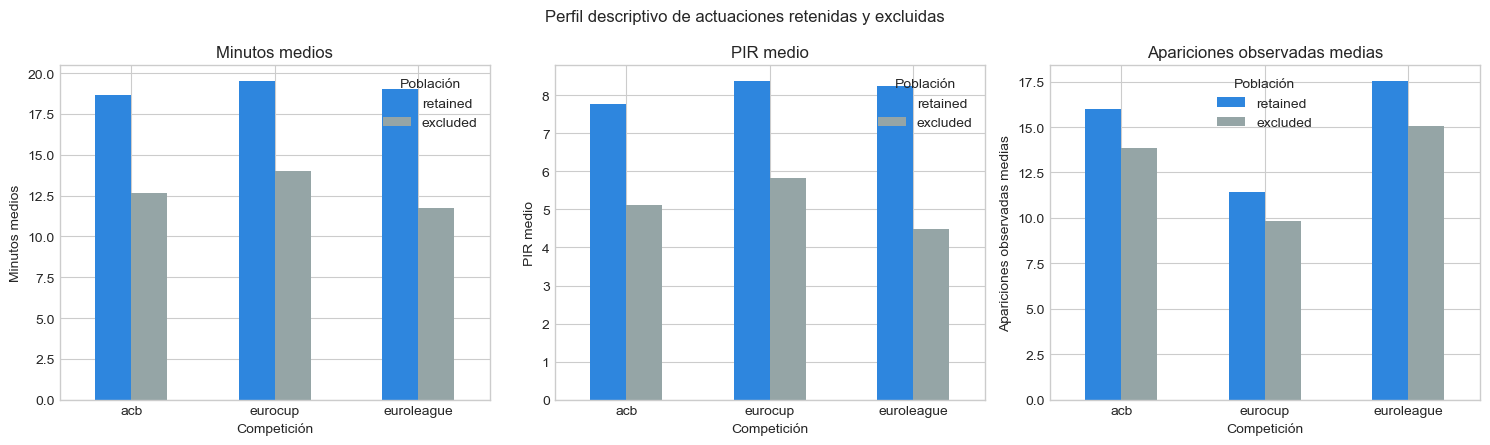

,competition,eligibility_status,rows,players,minutes_mean,minutes_median,pir_mean,pir_median,observed_appearances_mean,observed_appearances_median
0,acb,excluded,1011,272,12.651072,13.850000,5.110781,2.0,13.852621,16.0
1,acb,retained,2622,222,18.653617,19.466667,7.757437,7.0,15.991609,17.0
2,eurocup,excluded,1221,351,14.015930,14.916667,5.829648,3.0,9.809992,10.0
3,eurocup,retained,2095,287,19.492474,20.416667,8.362291,7.0,11.426253,12.0
4,euroleague,excluded,1076,245,11.717178,10.241667,4.474907,1.0,15.044610,17.0
5,euroleague,retained,2552,203,19.021284,19.916667,8.232759,7.0,17.511755,19.0


In [6]:
population_profile = clean.copy()
profile_keys = ["competition", "player_id", "match_id"]
eligible_keys = set(map(tuple, model_dataset[profile_keys].itertuples(index=False, name=None)))
population_profile["eligibility_status"] = [
    "retained" if key in eligible_keys else "excluded"
    for key in map(tuple, population_profile[profile_keys].itertuples(index=False, name=None))
]
population_profile["MP_min"] = pd.to_numeric(population_profile["MP_min"], errors="coerce")
population_profile["PIR"] = pd.to_numeric(population_profile["PIR"], errors="coerce")
population_profile["player_observed_appearances"] = population_profile.groupby(["competition", "player_id"])["match_id"].transform("size")

eligibility_profile = (population_profile.groupby(["competition", "eligibility_status"])
    .agg(rows=("match_id", "size"), players=("player_id", "nunique"),
         minutes_mean=("MP_min", "mean"), minutes_median=("MP_min", "median"),
         pir_mean=("PIR", "mean"), pir_median=("PIR", "median"),
         observed_appearances_mean=("player_observed_appearances", "mean"),
         observed_appearances_median=("player_observed_appearances", "median"))
    .reset_index())
assert set(eligibility_profile["eligibility_status"]) == {"retained", "excluded"}
assert eligibility_profile["rows"].sum() == 10_577
eligibility_profile.to_csv(TABLE_DIR / "eligibility_retained_excluded_profiles.csv", index=False)

profile_long = eligibility_profile.melt(
    id_vars=["competition", "eligibility_status"],
    value_vars=["minutes_mean", "pir_mean", "observed_appearances_mean"],
    var_name="indicator", value_name="mean_value",
)
profile_long.to_csv(TABLE_DIR / "figure_eligibility_profiles_source.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, indicator, label in zip(
    axes,
    ["minutes_mean", "pir_mean", "observed_appearances_mean"],
    ["Minutos medios", "PIR medio", "Apariciones observadas medias"],
):
    values = profile_long.query("indicator == @indicator")
    pivot = values.pivot(index="competition", columns="eligibility_status", values="mean_value")
    pivot[["retained", "excluded"]].plot(kind="bar", ax=ax, color=["#2e86de", "#95a5a6"])
    ax.set(title=label, xlabel="Competición", ylabel=label)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Población")
fig.suptitle("Perfil descriptivo de actuaciones retenidas y excluidas")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eligibility_retained_excluded_profiles.png", dpi=160, bbox_inches="tight")
plt.show()
display(eligibility_profile)

## Figuras finales

Se generan tres visualizaciones de síntesis: comparación de las tres métricas, compromiso MAE–RMSE y MAE por competición. Sus tablas fuente quedan preparadas para Power BI.

En R² un valor mayor es mejor; en MAE y RMSE un valor menor es mejor. Por eso no se combinan las tres métricas en un único ranking compuesto.

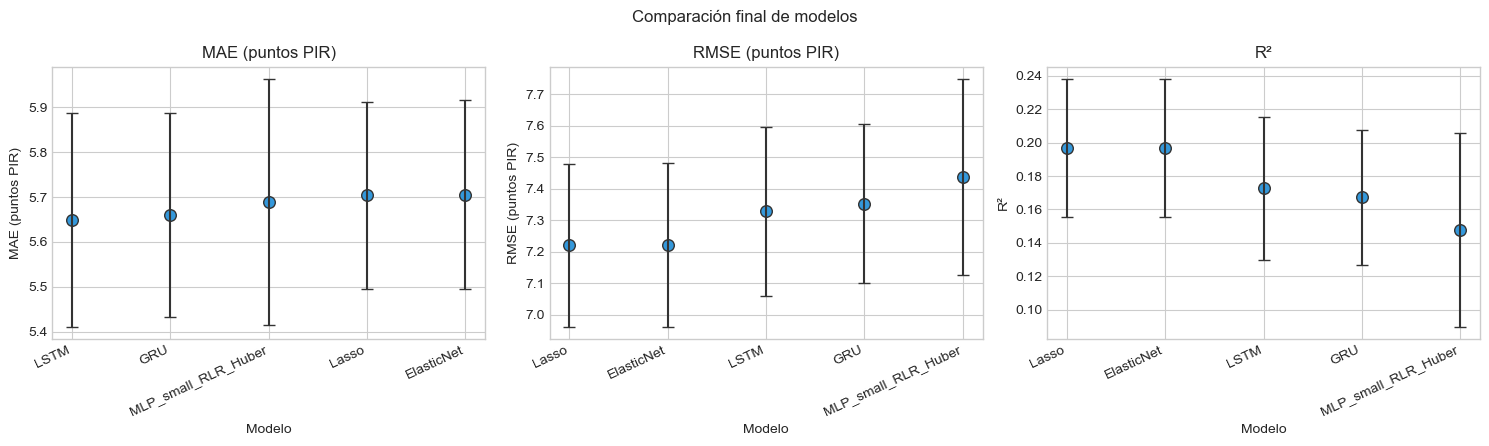

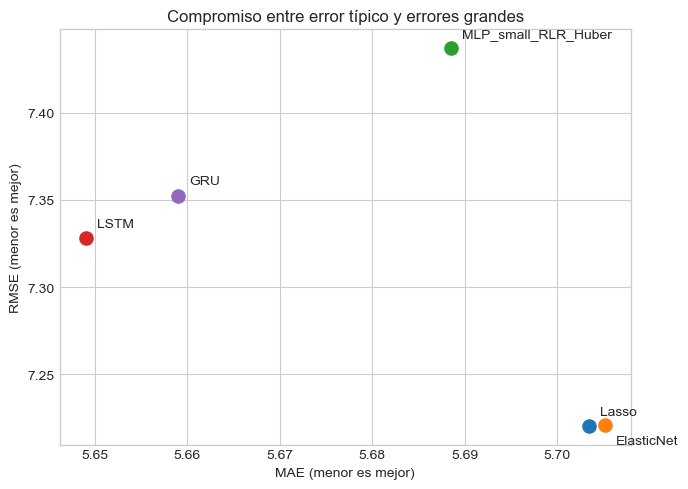

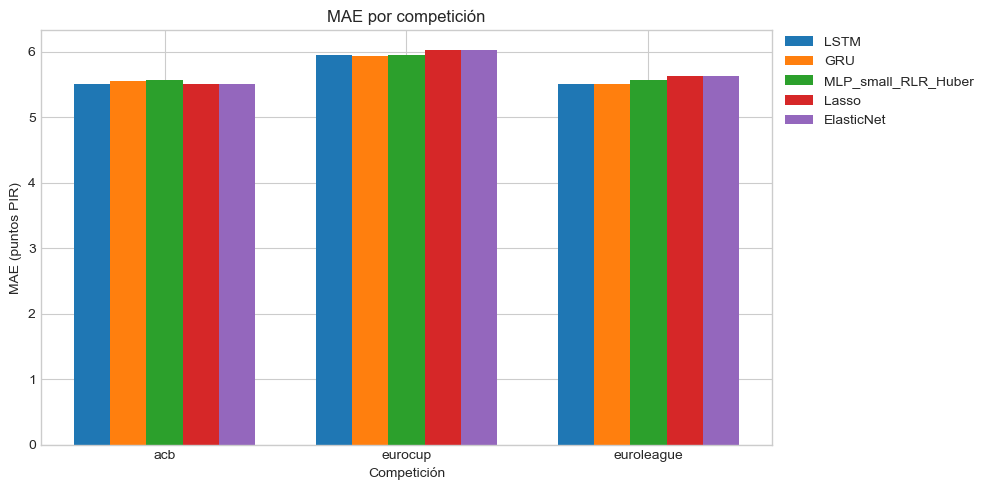

In [7]:
master_results.to_csv(TABLE_DIR / "figure_final_metrics_source.csv", index=False)
summary_by_competition.to_csv(TABLE_DIR / "figure_competition_mae_source.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric, label, lower_better in [
    (axes[0], "mae", "MAE (puntos PIR)", True),
    (axes[1], "rmse", "RMSE (puntos PIR)", True),
    (axes[2], "r2", "R²", False),
]:
    values = master_results.sort_values(f"{metric}_mean", ascending=lower_better)
    positions = np.arange(len(values))
    ax.errorbar(positions, values[f"{metric}_mean"], yerr=values[f"{metric}_std"], fmt="none", ecolor="#333333", capsize=4)
    ax.scatter(positions, values[f"{metric}_mean"], s=70, color="#3498db", edgecolor="#333333")
    ax.set(title=label, xlabel="Modelo", ylabel=label)
    ax.set_xticks(positions, values["model"], rotation=25, ha="right")
fig.suptitle("Comparación final de modelos")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "final_model_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
label_offsets = {
    "Lasso": (8, 8), "ElasticNet": (8, -14), "LSTM": (8, 8),
    "GRU": (8, 8), "MLP_small_RLR_Huber": (8, 8),
}
for _, row in master_results.iterrows():
    ax.scatter(row["mae_mean"], row["rmse_mean"], s=90)
    ax.annotate(row["model"], (row["mae_mean"], row["rmse_mean"]), xytext=label_offsets[row["model"]], textcoords="offset points")
ax.set(title="Compromiso entre error típico y errores grandes", xlabel="MAE (menor es mejor)", ylabel="RMSE (menor es mejor)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "mae_rmse_tradeoff.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
models = master_results.sort_values("mae_mean")["model"].tolist()
competitions = sorted(summary_by_competition["competition"].unique())
x = np.arange(len(competitions)); width = 0.15
for index, model in enumerate(models):
    values = summary_by_competition.query("model == @model").set_index("competition").reindex(competitions)
    ax.bar(x + (index - (len(models) - 1) / 2) * width, values["mae_mean"], width, label=model)
ax.set(title="MAE por competición", xlabel="Competición", ylabel="MAE (puntos PIR)", xticks=x, xticklabels=competitions)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_mae_by_competition.png", dpi=160, bbox_inches="tight")
plt.show()

## Conclusión práctica

El estudio utiliza 7.269 observaciones de 712 jugadores, 36 variables tabulares, secuencias de diez partidos, cinco folds temporales y tres semillas para Deep Learning.

En la comparación predictiva, LSTM obtiene el menor MAE (5,649), mientras que Lasso consigue el menor RMSE (7,220) y el mayor R² (0,197). ElasticNet queda prácticamente empatado con Lasso y proporciona la referencia utilizada para la interpretación. La mejora de MAE de LSTM frente a ElasticNet es inferior al 1 %.

Las redes recurrentes aprovechan una secuencia explícita de diez partidos y consiguen el mejor MAE, mientras que los modelos lineales regularizados conservan una ventaja en RMSE y R². La diferencia de MAE entre LSTM y ElasticNet es pequeña, por lo que el incremento de complejidad no produce una superioridad uniforme.

La forma reciente, el volumen ofensivo y el rendimiento sostenido dominan la predicción, aunque deben entenderse como asociaciones predictivas y no como efectos causales. El análisis de elegibilidad muestra además que la población retenida acumula más minutos, producción y apariciones observadas, una limitación que debe declararse al interpretar el alcance del modelo.

En respuesta al objetivo del TFM, Deep Learning aporta una mejora acotada en la métrica primaria, pero los métodos de Machine Learning regularizados siguen siendo competitivos, más sencillos y más fáciles de interpretar. Por ello, el resultado no justifica afirmar que una familia sea universalmente superior.

Como conclusión final, LSTM se presenta como el mejor resultado por MAE y la familia lineal Lasso–ElasticNet como la referencia más equilibrada e interpretable. ElasticNet se utiliza para analizar coeficientes y permutation importance. La comparación empírica queda así cerrada, manteniendo explícitos los compromisos entre precisión, estabilidad, complejidad e interpretabilidad.